<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum05"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv(path + "/data/Iris.csv")
# Menampilkan 5 baris pertama agar kita tahu isi datanya seperti apa
print("Data awal:")
print(df.head())


Data awal:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
# Kolom 'Id' tidak dibutuhkan karena hanya nomor urut saja, bukan data penting
data = df.drop(columns=['Id'])

# Pisahkan antara fitur (X) dan target (y)
X = data.drop(columns=['Species'])
y = data['Species']

# Membagi Data Menjadi Data Latih dan Data Uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Membuat model Decision Tree (pohon keputusan)
model = DecisionTreeClassifier(random_state=42)

# Melatih model menggunakan data training
model.fit(X_train, y_train)

# Konfirmasi Bahwa Model Sudah Siap
print("\n✅ Model Decision Tree berhasil dibuat dan dilatih!")


✅ Model Decision Tree berhasil dibuat dan dilatih!


In [ ]:
# Model yang sudah dilatih akan mencoba memprediksi data testing
y_pred = model.predict(X_test)

# Mengukur Akurasi Model
akurasi = accuracy_score(y_test, y_pred)
print("Akurasi Model Decision Tree:", round(akurasi * 100, 2), "%")

# Menampilkan Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Menampilkan Laporan Klasifikasi
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

print("\n✅ Evaluasi model selesai! Model siap digunakan untuk pengujian.")


Akurasi Model Decision Tree: 100.0 %

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Laporan Klasifikasi:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


✅ Evaluasi model selesai! Model siap digunakan untuk pengujian.


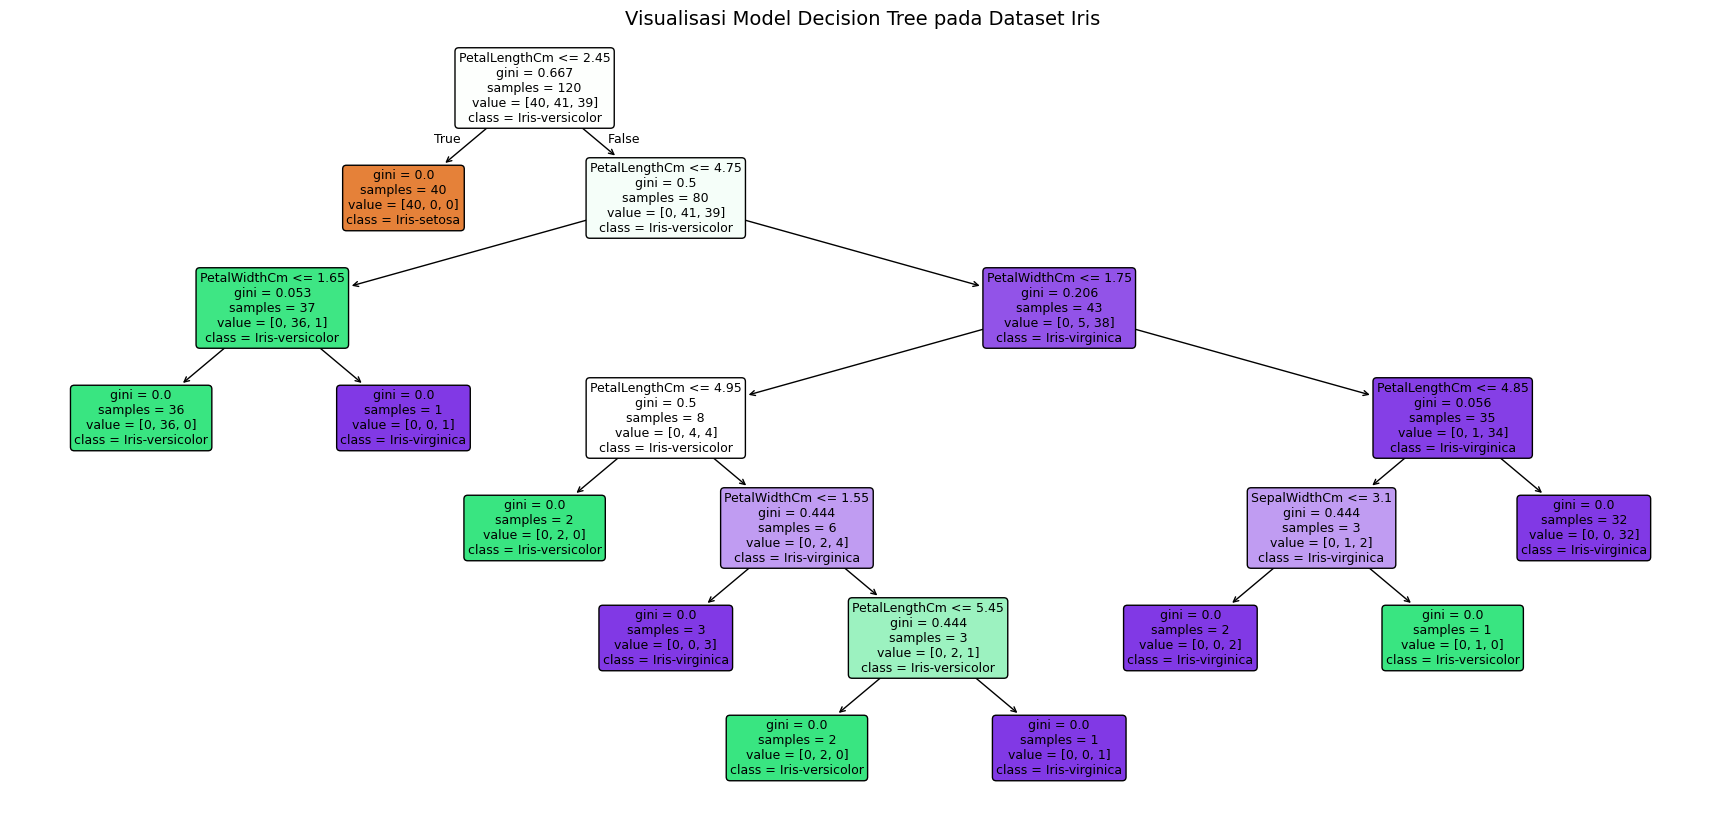

In [ ]:
# VISUALISASI POHON KEPUTUSAN (DECISION TREE)
plt.figure(figsize=(22, 10))  # mengatur ukuran gambar agar pohon terlihat jelas

# Menggambar Pohon Keputusan
# - 'feature_names' digunakan agar kolom terlihat namanya (bukan angka)
# - 'class_names' agar label target ditampilkan sesuai nama species
# - 'filled=True' memberi warna untuk membedakan setiap kelas
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,       # sudut kotak dibulatkan agar lebih rapi
    fontsize=9          # ukuran teks agar mudah dibaca
)

# Menampilkan Gambar Pohon
plt.title("Visualisasi Model Decision Tree pada Dataset Iris", fontsize=14)
plt.show()


In [ ]:
# Menampilkan Data Testing
print("Beberapa data testing (fitur):")
print(X_test.head())  # menampilkan 5 data pertama dari data testing

# Melakukan Prediksi dengan Model
prediksi = model.predict(X_test)

# Menampilkan hasil prediksi model
print("\nHasil prediksi model untuk data testing:")
print(prediksi)

# Membandingkan Hasil Prediksi dengan Nilai Asli
# Ini untuk melihat apakah model benar menebak jenis bunga
print("\nPerbandingan hasil prediksi vs nilai sebenarnya:")
hasil = pd.DataFrame({
    'SepalLengthCm': X_test['SepalLengthCm'],
    'SepalWidthCm': X_test['SepalWidthCm'],
    'PetalLengthCm': X_test['PetalLengthCm'],
    'PetalWidthCm': X_test['PetalWidthCm'],
    'Species_Asli': y_test.values,      # nilai sebenarnya
    'Species_Prediksi': prediksi        # hasil dari model
})

# Menampilkan hasil perbandingan
print(hasil.head())

# Menyimpulkan Hasil
print("\n✅ Model telah diuji menggunakan data testing.")


Beberapa data testing (fitur):
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
73             6.1           2.8            4.7           1.2
18             5.7           3.8            1.7           0.3
118            7.7           2.6            6.9           2.3
78             6.0           2.9            4.5           1.5
76             6.8           2.8            4.8           1.4

Hasil prediksi model untuk data testing:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']

Perbandingan hasil prediksi vs nilai sebenarnya:
     Se